Loaded 823 articles from ../data/raw_articles.json


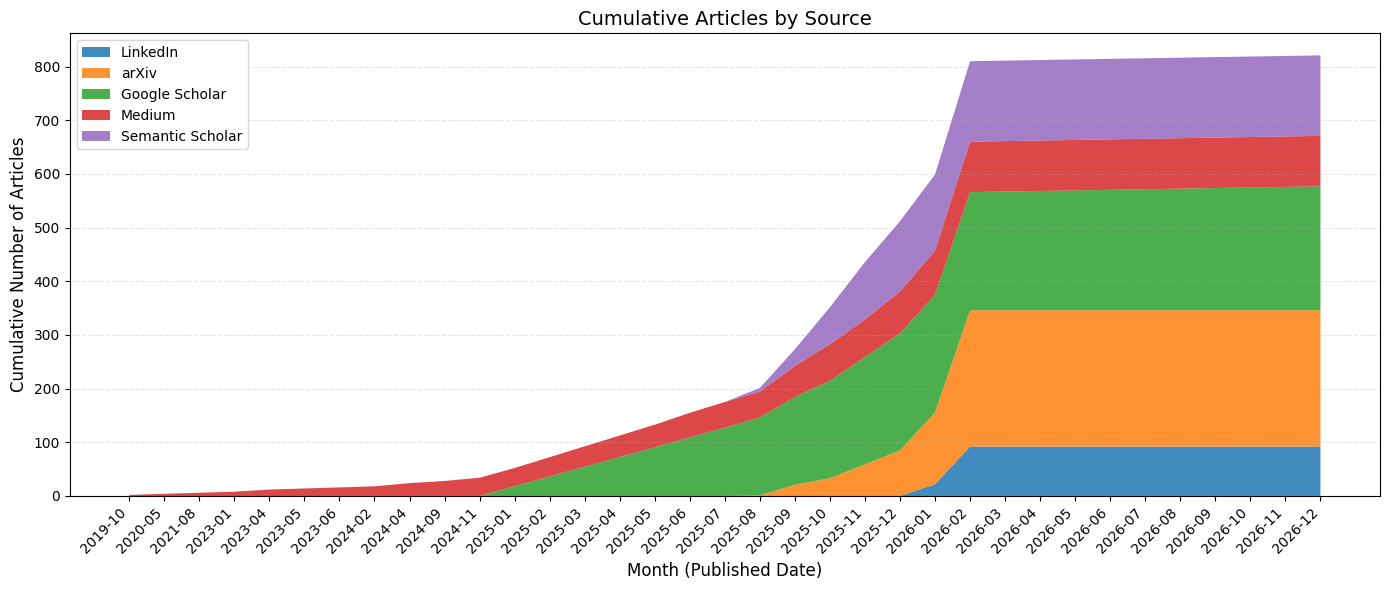


Total articles in chart (by source):
  LinkedIn: 92.0
  arXiv: 254.0
  Google Scholar: 231.0
  Medium: 94.0
  Semantic Scholar: 150.0


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from datetime import datetime

# 1. Load Data
file_path = "../data/raw_articles.json"

try:
    with open(file_path, "r", encoding="utf-8") as f:
        all_articles = json.load(f)
    print(f"Loaded {len(all_articles)} articles from {file_path}")
except FileNotFoundError:
    print(f"Error: File not found at {file_path}")
    exit()

# 2. Configuration
sources = [
    ("linkedin", "LinkedIn"),
    ("arxiv", "arXiv"),
    ("google_scholar", "Google Scholar"),
    ("medium", "Medium"),
    ("semantic_scholar", "Semantic Scholar"),
]

def to_month_key(d):
    """Convert valid date string to 'YYYY-MM'."""
    if not d or not isinstance(d, str) or d.startswith("NA"):
        return None
    try:
        if len(d) >= 7:
            # Parses YYYY-MM from YYYY-MM-DD
            dt = datetime.strptime(d[:7], "%Y-%m")
            return dt.strftime("%Y-%m")
        return None
    except (ValueError, TypeError):
        return None

def is_usable_month_date(source_key, date_str):
    """Check if date is usable for monthly plotting."""
    if not date_str or date_str.startswith("NA"):
        return False
    # Specific logic: Google Scholar 'YYYY-01-01' is handled separately
    if source_key == "google_scholar" and date_str.endswith("-01-01"):
        return False
    return to_month_key(date_str) is not None

# 3. Process Data
# counts[source_key][month] = count
counts = {sk: defaultdict(float) for sk, _ in sources}

# Separate tracker for Scholar's year-only dates
scholar_year_only = defaultdict(int)

for article in all_articles:
    sk = article.get("source")
    # Ensure source is one we are tracking
    if sk not in counts:
        continue

    date_str = article.get("published_date")
    
    # Handle Google Scholar Year-Only (YYYY-01-01)
    if sk == "google_scholar" and date_str and date_str.endswith("-01-01"):
        # Extract year if possible
        if date_str[:4].isdigit():
            scholar_year_only[int(date_str[:4])] += 1
        continue

    # Handle standard dates
    if is_usable_month_date(sk, date_str):
        month = to_month_key(date_str)
        if month:
            counts[sk][month] += 1

# Distribute Scholar year-only counts evenly across 12 months
for year, n in scholar_year_only.items():
    if n > 0:
        per_month = n / 12.0
        for m in range(1, 13):
            month_key = f"{year}-{m:02d}"
            counts["google_scholar"][month_key] += per_month

# Collect all unique months present in the data
all_months = sorted(set().union(*(set(counts[sk].keys()) for sk, _ in sources)))

if not all_months:
    print("No valid dated data found to plot.")
    exit()

# 4. Plotting
# Prepare data for stackplot
raw_series = [[counts[sk].get(m, 0) for m in all_months] for sk, _ in sources]
cumulative_series = [np.cumsum(s) for s in raw_series]
labels = [label for _, label in sources]

fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(all_months))

# Create Stackplot
ax.stackplot(x, *cumulative_series, labels=labels, alpha=0.85)

# X-Axis Formatting: Show a label every N months to prevent crowding
step = max(1, len(all_months) // 20)
ax.set_xticks(x[::step])
ax.set_xticklabels(all_months[::step], rotation=45, ha="right", fontsize=10)

# Labels and Title
ax.set_xlabel("Month (Published Date)", fontsize=12)
ax.set_ylabel("Cumulative Number of Articles", fontsize=12)
ax.set_title("Cumulative Articles by Source", fontsize=14)
ax.legend(loc="upper left", fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Print Stats
in_chart = {label: round(sum(counts[sk].values()), 1) for sk, label in sources}
print("\nTotal articles in chart (by source):")
for source, count in in_chart.items():
    print(f"  {source}: {count}")